# Buổi 4 — Mức độ gắn bó

Câu hỏi cần trả lời: ngoài việc có quay lại hay không (retention), người chơi ở hai nhóm gate_30/gate_40 có chơi nhiều/ít khác nhau không (`sum_gamerounds`)? Vì phân bố này lệch phải rất mạnh (đã thấy ở Buổi 1), không dùng kiểm định giả định phân phối chuẩn — dùng Mann-Whitney U.

## 1. So sum_gamerounds giữa hai nhóm — Mann-Whitney U

In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/cookie_cats.csv')

In [2]:
from scipy.stats import mannwhitneyu

nhom_30 = df[df['version'] == 'gate_30']['sum_gamerounds']
nhom_40 = df[df['version'] == "gate_40"]["sum_gamerounds"]

stat, p_value = mannwhitneyu(nhom_30, nhom_40, alternative="two-sided")
print(f"Statistic: {stat}, p-value: {p_value}")

Statistic: 1024331250.5, p-value: 0.05020880772044255


## 2. Tính effect size

In [3]:
n1 = len(nhom_30)
n2 = len(nhom_40)

effect_size_r = 1 - (2 * stat) / (n1 * n2)
print(f"Effect Size (r): {effect_size_r}")

Effect Size (r): -0.007526563813175402


## 3. So cả trung vị lẫn trung bình, giải thích vì sao chúng lệch nhau

In [4]:
df.groupby("version")["sum_gamerounds"].agg(["mean", "median"])

,mean,median
version,,
gate_30,52.456264,17.0
gate_40,51.298776,16.0


**Giải thích vì sao trung bình và trung vị lệch nhau:** gate_30 có mean=52,46 nhưng median chỉ 17,0; gate_40 có mean=51,30 nhưng median chỉ 16,0 — trung bình cao hơn trung vị gần gấp 3 lần ở cả hai nhóm. Đây là hệ quả trực tiếp của phân bố lệch phải rất mạnh đã xác nhận ở Buổi 1: đa số người chơi chỉ chơi vài chục vòng (trung vị phản ánh đúng "người chơi điển hình"), nhưng một số ít người chơi rất nhiều vòng — đặc biệt là ca cực đại 49.854 vòng đã xác định là khả năng cao là bot — kéo trung bình lên cao hơn hẳn so với trải nghiệm thực tế của phần lớn người chơi. Vì vậy trung vị là con số đáng tin hơn để mô tả "người chơi điển hình", còn trung bình dễ gây hiểu lầm nếu dùng một mình.

## 4. Vẽ đường retention theo mốc số vòng chơi — người chơi rơi rụng ở quanh đâu?

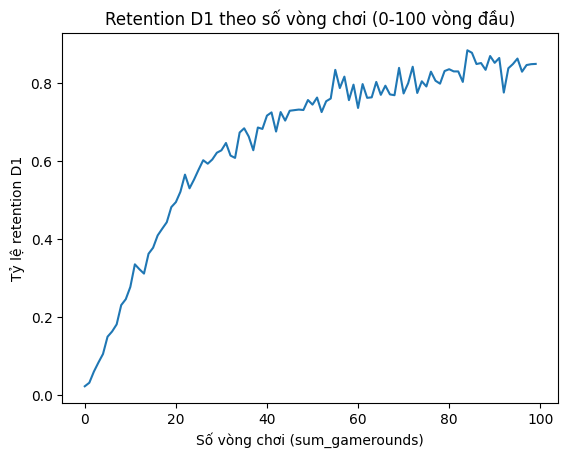

In [5]:
import matplotlib.pyplot as plt

ty_le_theo_vong = df.groupby("sum_gamerounds")["retention_1"].mean()

plt.plot(ty_le_theo_vong.iloc[:100])
plt.xlabel("Số vòng chơi (sum_gamerounds)")
plt.ylabel("Tỷ lệ retention D1")
plt.title("Retention D1 theo số vòng chơi (0-100 vòng đầu)")
plt.show()

**Đọc biểu đồ:** tỷ lệ retention D1 tăng dốc từ ~2% (0 vòng) lên khoảng 80-85% khi số vòng chơi vượt ~60, sau đó gần như đi ngang. Vùng "rơi rụng" nặng nhất — nơi tỷ lệ quay lại thấp và tăng nhanh nhất — là **0-20 vòng đầu**: phần lớn người chơi bỏ cuộc rất sớm, trước khi kịp trải nghiệm sâu vào game.

**Giới hạn khi đọc biểu đồ này:** `sum_gamerounds` đếm tổng số vòng trong toàn bộ 14 ngày, không chỉ trước mốc D1 — người có `retention_1=True` đương nhiên có thêm 13 ngày để tích luỹ thêm vòng chơi so với người rời bỏ ngay ngày đầu. Vì vậy biểu đồ vừa phản ánh đúng quan hệ "chơi nhiều hơn → gắn bó hơn", vừa mang một phần hệ quả tất yếu của cách đo (ai còn ở lại thì có nhiều ngày hơn để cộng dồn số vòng) — không tách bạch hoàn toàn được nhân và quả chỉ từ dữ liệu này.

## Kết quả, Đề xuất, Giới hạn

- Kết quả:
    Mức độ gắn bó (`sum_gamerounds`) giữa gate_30 và gate_40 gần như không khác nhau: Mann-Whitney U cho p=0,0502 (ngay sát ngưỡng 0,05, chưa đủ bằng chứng để khẳng định có khác biệt) và effect size (r) = -0,0075 — gần bằng 0, tức không có khác biệt đáng kể về thực chất dù p-value có nằm sát ngưỡng. Cả hai nhóm đều có trung bình cao hơn trung vị gần 3 lần (gate_30: mean=52,46/median=17,0; gate_40: mean=51,30/median=16,0), phản ánh đúng phân bố lệch phải mạnh đã biết từ Buổi 1. Biểu đồ retention D1 theo số vòng chơi cho thấy vùng rơi rụng nặng nhất là 0-20 vòng đầu, sau đó retention tăng dần và ổn định quanh 80-85% từ ~60 vòng trở lên.

- Đề xuất:
    Kết quả buổi này không làm thay đổi đề xuất đã đưa ở Buổi 2-3 (giữ nguyên gate_30) — nó bổ sung thêm góc nhìn: dời gate ảnh hưởng đến việc người chơi "có quay lại hay không" (retention D7, đã có ý nghĩa thống kê) nhiều hơn là ảnh hưởng đến "chơi nhiều hay ít" ở những người vẫn còn chơi (không có khác biệt đáng kể). Về sản phẩm, đáng đầu tư cải thiện trải nghiệm ở vùng 0-20 vòng đầu tiên, vì đó là nơi mất người chơi nhiều nhất, bất kể gate đặt ở đâu.

- Giới hạn:
    Effect size gần 0 không đồng nghĩa "chắc chắn không có khác biệt" — chỉ là chưa đủ bằng chứng để khẳng định có, đặc biệt khi p-value nằm sát ngưỡng 0,05. Biểu đồ retention theo số vòng chơi ở phần 4 có giới hạn về nhân quả: `sum_gamerounds` đếm cả 14 ngày, nên người được giữ lại đương nhiên có nhiều ngày hơn để cộng dồn vòng chơi — không tách bạch hoàn toàn được chiều nhân quả giữa "chơi nhiều nên ở lại" và "ở lại nên có nhiều ngày để chơi nhiều".